Implement a feature fusion upsampler that uses shift features upsampling instead of bilinear 

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"

sys.path.append(global_path)
from NAF.src.model import naf

# global_path = "/home/edabier/Documents/Thèse/benchmark"
# global_path = "/Users/edabier/Documents/Thèse/Thèse_Télécom"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
sys.path.append(f"{global_path}/SS-HSU_benchmark")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models, upsamplers, foundation_models as rsfm, unmixers as unmx

sys.path.append(f"{global_path}/spectral_earth")
from spectral_earth.src.backbones import spectral_adapter

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [36]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
Y_init = Y_init.unsqueeze(0)
Y_init_n = utils.standardise(Y_init)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]
    
new_H = 224
Y_init_fm = F.interpolate(Y_init, size=(new_H, new_H))

In [37]:
dofa, _, new_H = rsfm.create_fm("DOFA", Y_init, size="large", version="v1", path=global_path)

_, features_dofa = rsfm.extract_f(dofa, Y_init, 224, wavelengths)
Y_init_fm, A_init_fm = rsfm.reshape_Y("DOFA", Y_init, 224, A_init)

D_dofa = int(features_dofa.shape[0])
alpha_dofa = int(features_dofa.shape[1]**0.5)

# plots.plot_pca_features(features_dofa)

In [38]:
class FeaturesFusionUpsampler(nn.Module):
    def __init__(self, C, B, alpha, H):
        super().__init__()
        self.C = C
        self.B = B
        self.alpha = alpha
        self.H = H

        self.upsample = nn.Conv2d(C, C, kernel_size=3, padding=1, groups=C)

        self.extract_hr = nn.Conv2d(B, C, kernel_size=1)

        self.fuse = nn.Sequential(
            nn.Conv2d(2 * C, C, kernel_size=3, padding=1, groups=C),
            nn.BatchNorm2d(C),
            nn.LeakyReLU(0.01),
        )

    def forward(self, x_lr, x_hr):
        # x_lr: (batch, C, alpha, alpha)
        # x_hr: (batch, B, H, H)

        x_upsampled = self.upsample(x_lr)
        x_hr_feat = self.extract_hr(x_hr)
        x_fused = torch.cat([x_upsampled, x_hr_feat], dim=1)
        x_fused = self.fuse(x_fused)

        return x_fused

In [39]:
class UnmixingFromFeatures(nn.Module):
    def __init__(self, D, B, c, H=224, alpha=None, n_features=1):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFromFeatures, self).__init__()
        self.D = D
        self.alpha = alpha
        self.B = B
        self.c = c
        self.H = H
        self.n_features = n_features

        # Upsampling features
        self.upsample = FeaturesFusionUpsampler(self.n_features*D, B, alpha, H)

        # Upsampled features to abundances
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(self.n_features*D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, features_hr=None, features_lr=None, channel_selector=None, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0, W_mse=0.09, W_e=0, W_feat=0, W_tv_feat=0, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Feature regularisation"""

        if features_hr != None:
            l1 = nn.L1Loss()
            downsample = nn.AdaptiveAvgPool2d(features_lr[0].shape)
            features_down = downsample(features_hr)

            loss_features = W_feat * l1(utils.normalize(features_down), utils.normalize(features_lr))
        
        else:
            loss_features = 0

        loss = loss_sad + loss_ab + loss_mse + loss_features

        if channel_selector != None:
            loss += torch.linalg.norm(channel_selector, dim=0, ord=1)#/ len(channel_selector)

        if return_losses:
            return loss, loss_sad, loss_ab, loss_mse
        else:
            return loss

    def get_abundances(self, features, Y):

        features_up = self.upsample(features, Y)
        
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features, Y):
        A_hat = self.get_abundances(features, Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

### Classic features fusion

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.149, NMSE = 0.128
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.152, NMSE = 0.128
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.152, NMSE = 0.138
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.150, NMSE = 0.135
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.148, NMSE = 0.137
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.152, NMSE = 0.131
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.152, NMSE = 0.127

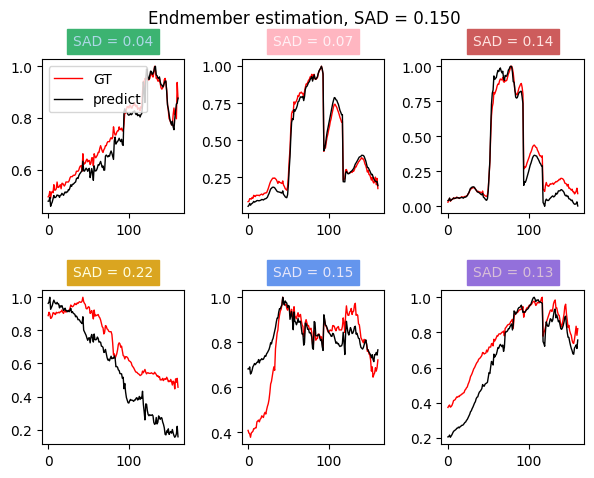

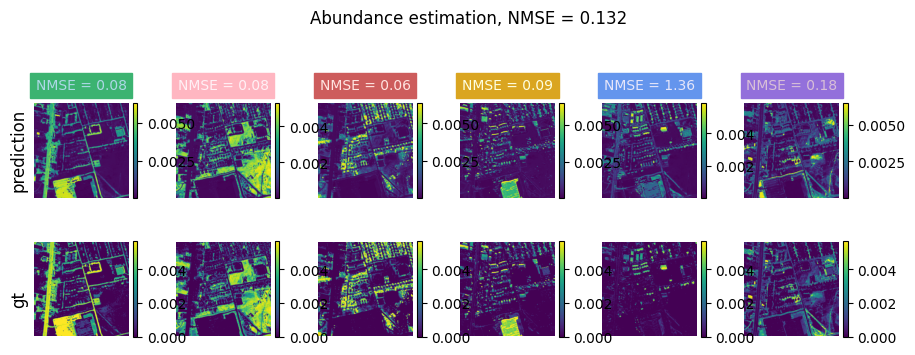

In [40]:
# features_map = rsfm.upsample_features(dofa, Y_init_fm, wavelengths, new_H, D_dofa, alpha_dofa)
n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(upsampler="Features_fusion", D=D_dofa, alpha=alpha_dofa, H=new_H, B=B, c=c, n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_fm/Y_init_fm.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):
        
        for Y, _, _ in loader:
    
            optimizer.zero_grad()
            Y = utils.oneD_to_2d(Y).to(dev)

            Y_fm, features = rsfm.extract_f(dofa, Y, new_H, wavelengths)
            E_hat, A_hat, Y_hat = model(features, Y_init_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        Y_fm, A_init_fm, features = rsfm.extract_f(dofa, Y, new_H, wavelengths, A_init)
        E_hat, A_hat, Y_hat = model(features, Y_init_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Upsampler has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')} NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### NAF upsampling features fusion

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.161, NMSE = 0.114
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.168, NMSE = 0.112
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.141, NMSE = 0.131
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.150, NMSE = 0.134
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.156, NMSE = 0.114
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.165, NMSE = 0.150
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.158, NMSE = 0.120

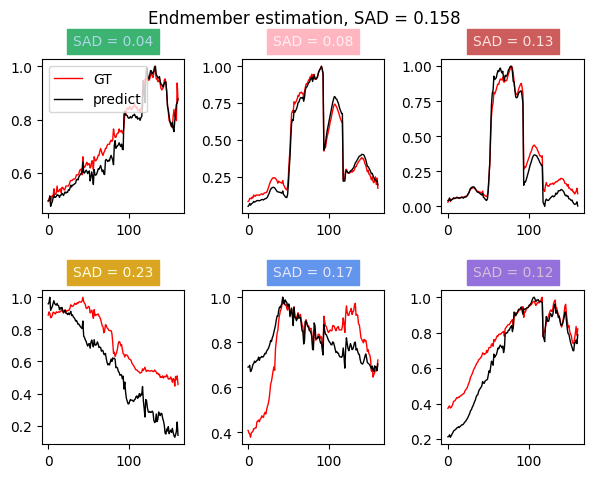

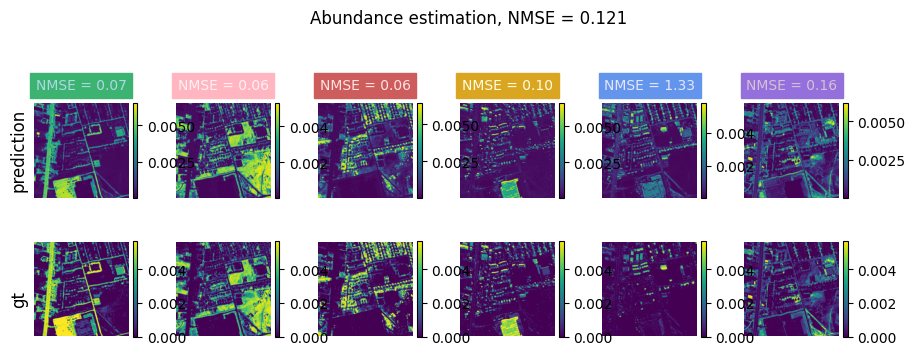

In [41]:
naf_model = naf.NAF(in_channels=128, kernel_size=7)
checkpoint = torch.load(f"{global_path}/spectral_earth/data/data/spec_ViTb_mae.pth", map_location=dev)
spectral_adapter_state_dict = {
    key.replace("spectral_adapter.", ""): value
    for key, value in checkpoint.items()
    if key.startswith("spectral_adapter.")
}
adapter = spectral_adapter.SpectralAdapter()
adapter.load_state_dict(spectral_adapter_state_dict, strict=False)

with torch.no_grad():
    Y_adapted = adapter(Y_init)
    features_map = naf_model(Y_adapted, utils.oneD_to_2d(features_dofa).unsqueeze(0), output_size=(new_H, new_H))

n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeatures(D=D_dofa, alpha=alpha_dofa, H=new_H, B=B, c=c, n_features=1)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_fm/Y_init_fm.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):
    
        optimizer.zero_grad()
        
        E_hat, A_hat, Y_hat = model(features_map, Y_init_fm)

        loss = model.loss(Y_init_fm, Y_hat, A_hat, E_hat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        E_hat, A_hat, _ = model(features_map, Y_init_fm)
        # upsampled_features[i] = model.upsample(features_map, Y_init_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')} NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

plt.show()
# plots.plot_pca_features(upsampled_features[0].flatten(1))

### Features fusion ablation

In [42]:
class FeaturesFusionUpsamplerAblation(nn.Module):
    def __init__(self, C, B):
        super().__init__()
        self.C = C
        self.B = B

        self.extract_hr = nn.Conv2d(B, C, kernel_size=1)

        self.fuse = nn.Sequential(
            nn.Conv2d(C, C, kernel_size=3, padding=1, groups=C),
            nn.BatchNorm2d(C),
            nn.LeakyReLU(0.01),
        )

    def forward(self, x_hr):
        # x_hr: (batch, B, H, H)

        x_hr_feat = self.extract_hr(x_hr)
        x_fused = self.fuse(x_hr_feat)

        return x_fused

class UnmixingFromFeaturesAblation(nn.Module):
    def __init__(self, D, B, c, H=224):
        """
        Upsamples low res features then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi

        """
        super(UnmixingFromFeaturesAblation, self).__init__()
        self.D = D
        self.B = B
        self.c = c
        self.H = H

        # Upsampling features
        self.upsample = FeaturesFusionUpsamplerAblation(D, B)

        # Upsampled features to abundances
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.sum_to_one = unmx.Sum_to_one()
        self.decoder = unmx.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, features_hr=None, features_lr=None, channel_selector=None, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0, W_mse=0.09, W_e=0, W_feat=0, W_tv_feat=0, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Feature regularisation"""

        if features_hr != None:
            l1 = nn.L1Loss()
            downsample = nn.AdaptiveAvgPool2d(features_lr[0].shape)
            features_down = downsample(features_hr)

            loss_features = W_feat * l1(utils.normalize(features_down), utils.normalize(features_lr))
        
        else:
            loss_features = 0

        loss = loss_sad + loss_ab + loss_mse + loss_features

        if channel_selector != None:
            loss += torch.linalg.norm(channel_selector, dim=0, ord=1)#/ len(channel_selector)

        if return_losses:
            return loss, loss_sad, loss_ab, loss_mse
        else:
            return loss

    def get_abundances(self, Y):

        Y = self.upsample(Y)
        # features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(Y)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, Y):
        A_hat = self.get_abundances(Y)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

training 1/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.158, NMSE = 0.116
training 2/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.154, NMSE = 0.116
training 3/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.162, NMSE = 0.121
training 4/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.157, NMSE = 0.112
training 5/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.157, NMSE = 0.110
training 6/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.155, NMSE = 0.120
training 7/15
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.180, NMSE = 0.131

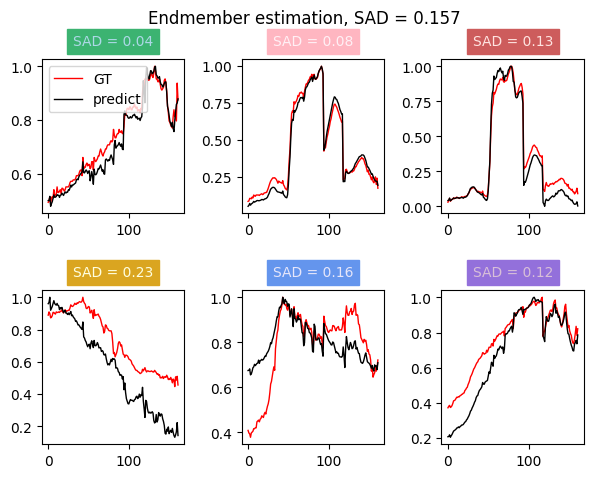

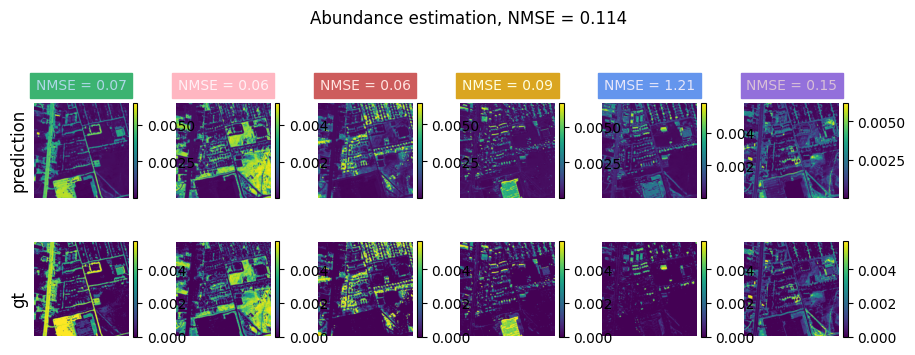

In [43]:
n_xp = 15
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFromFeaturesAblation(D=D_dofa, H=new_H, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_fm/Y_init_fm.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()
            Y = utils.oneD_to_2d(Y).to(dev)
            Y_fm = rsfm.reshape_Y("DOFA", Y, new_H)
            
            E_hat, A_hat, Y_hat = model(Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        Y_fm, A_fm = rsfm.reshape_Y("DOFA", Y, new_H, A_init)
        E_hat, A_hat, _ = model(Y_fm)
        # upsampled_features[i] = model.upsample(features_map, Y_init_fm)

        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_fm, E_init, normalize_E=True, normalize_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_fm, E_init, normalize_E=True, normalize_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')} NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

plt.show()
# plots.plot_pca_features(upsampled_features[0].flatten(1))